# Motor Claims Fraud Triage

**Portfolio project — synthetic data only.** No customer, policyholder, claim, or employer-confidential data is used anywhere in this notebook. See `../README.md` for the full case study writeup.

This notebook walks through the same pipeline as `src/generate_data.py` and `src/train_model.py`, with the reasoning shown at each step.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from generate_data import generate_claims

df = generate_claims()
print(f"{len(df):,} synthetic claims generated")
print(f"Fraud rate: {df['fraud_flag'].mean():.2%}")
df.head()

8,000 synthetic claims generated
Fraud rate: 4.66%


,claim_id,policy_type,region,claim_type,claim_amount,policy_tenure_months,claimant_age,prior_claims_count,days_to_report,police_report_filed,fraud_flag
0,MC-80000,Agricultural,KwaZulu-Natal,Hail Damage,11873.79,9,39,0,4,True,0
1,MC-80001,Motor,Western Cape,Hijacking,11326.28,28,38,0,6,False,0
2,MC-80002,Agricultural,KwaZulu-Natal,Equipment Damage,22715.80,36,55,0,6,False,0
3,MC-80003,Motor,Western Cape,Theft,23247.76,12,44,0,4,True,0
4,MC-80004,Motor,Gauteng,Fire,43821.03,16,31,1,2,True,0


## The problem

Fraud is rare (under 5% of claims here, in line with published order-of-magnitude estimates for short-term insurance fraud), which creates two failure modes to design around:

1. **Naive accuracy is meaningless.** A model that predicts "not fraud" for every claim scores ~95% accuracy while catching zero fraud.
2. **A fixed probability threshold doesn't work either**, for the same reason — predicted probabilities for a rare event rarely approach 0.5 even for genuine positives. Both are demonstrated below rather than glossed over.

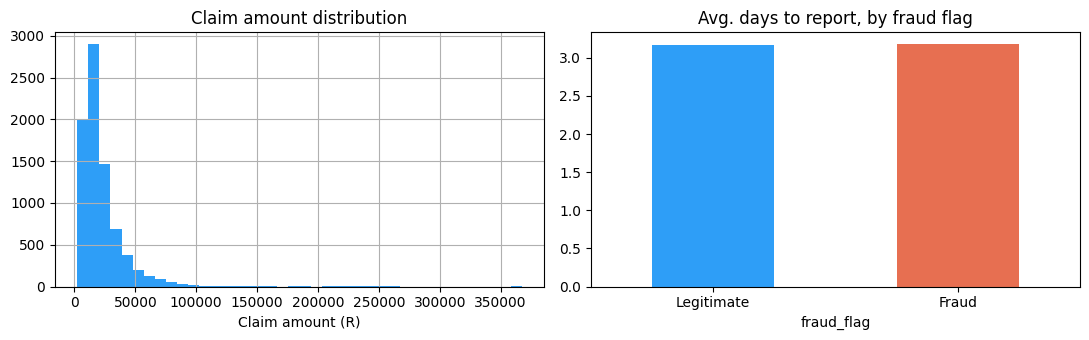

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df['claim_amount'].hist(bins=40, ax=axes[0], color='#2E9EF7')
axes[0].set_title('Claim amount distribution')
axes[0].set_xlabel('Claim amount (R)')

df.groupby('fraud_flag')['days_to_report'].mean().plot(kind='bar', ax=axes[1], color=['#2E9EF7', '#E76F51'])
axes[1].set_title('Avg. days to report, by fraud flag')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('../results/data_overview.png', dpi=110)
plt.show()

## Feature engineering and model

Numeric fields go in as-is; `policy_type`, `region`, and `claim_type` are one-hot encoded. The train/test split is stratified on the fraud label, and **SMOTE is applied only to the training fold**, after the split — applying it before splitting would leak synthetic minority-class information into the test set and inflate every metric below.

In [3]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import sys
sys.path.insert(0, '../src')
from train_model import build_features, evaluate_at_threshold, evaluate_at_flag_rate, get_top_features

X, y, feature_names = build_features(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Train: {len(X_train):,} claims ({y_train.mean():.2%} fraud) -> {len(X_train_res):,} after SMOTE")
print(f"Test:  {len(X_test):,} claims ({y_test.mean():.2%} fraud) — untouched by SMOTE")

model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.06,
    subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', random_state=42,
)
model.fit(X_train_res, y_train_res)
y_prob = model.predict_proba(X_test)[:, 1]
print("Model trained.")

Train: 6,000 claims (4.67% fraud) -> 11,440 after SMOTE
Test:  2,000 claims (4.65% fraud) — untouched by SMOTE


Model trained.


## The naive-threshold trap, demonstrated

Flagging everything with predicted probability ≥ 0.5:

In [4]:
from sklearn.metrics import roc_auc_score

naive = evaluate_at_threshold(y_test, y_prob, 0.5)
print(f"Accuracy:  {naive['accuracy']:.1%}   <- looks great")
print(f"Recall:    {naive['recall']:.1%}   <- catches ~nothing")
print(f"Precision: {naive['precision']:.1%}")
print(f"\nROC-AUC (threshold-independent): {roc_auc_score(y_test, y_prob):.3f}")
print("The model has learned a real, if modest, signal (AUC well above 0.5) —")
print("the 0.5 threshold is simply the wrong tool for a ~5% base rate.")

Accuracy:  95.2%   <- looks great
Recall:    0.0%   <- catches ~nothing
Precision: 0.0%

ROC-AUC (threshold-independent): 0.719
The model has learned a real, if modest, signal (AUC well above 0.5) —
the 0.5 threshold is simply the wrong tool for a ~5% base rate.


## The actual operating strategy: flag a review capacity, not a probability

In practice, a fraud team has a fixed number of claims it can manually review per period. The realistic question isn't "which claims exceed probability 0.5" — it's "if we can review the riskiest 10% of claims, how much fraud do we catch, and how many of those reviews turn out to be unnecessary?" That's what this table answers.

In [5]:
sweep = pd.DataFrame([evaluate_at_flag_rate(y_test, y_prob, r) for r in (0.05, 0.10, 0.15, 0.20)])
sweep_display = sweep[['flag_rate', 'n_flagged', 'precision', 'recall', 'false_positive_rate']].copy()
sweep_display['flag_rate'] = (sweep_display['flag_rate'] * 100).astype(int).astype(str) + '%'
sweep_display['precision'] = (sweep_display['precision'] * 100).round(1).astype(str) + '%'
sweep_display['recall'] = (sweep_display['recall'] * 100).round(1).astype(str) + '%'
sweep_display['false_positive_rate'] = (sweep_display['false_positive_rate'] * 100).round(1).astype(str) + '%'
sweep_display.columns = ['Claims flagged', 'N flagged', 'Precision', 'Recall', 'False positive rate']
sweep_display

,Claims flagged,N flagged,Precision,Recall,False positive rate
0,5%,100,12.0%,12.9%,4.6%
1,10%,200,12.5%,26.9%,9.2%
2,15%,300,13.3%,43.0%,13.6%
3,20%,400,12.0%,51.6%,18.5%


In [6]:
base_rate = y_test.mean()
top10 = evaluate_at_flag_rate(y_test, y_prob, 0.10)
lift = top10['precision'] / base_rate
print(f"Reviewing the riskiest 10% of claims catches {top10['recall']:.0%} of all fraud,")
print(f"at {lift:.1f}x the hit rate of reviewing claims at random ({top10['precision']:.1%} vs {base_rate:.1%} precision).")

Reviewing the riskiest 10% of claims catches 27% of all fraud,
at 2.7x the hit rate of reviewing claims at random (12.5% vs 4.7% precision).


## What's driving the model

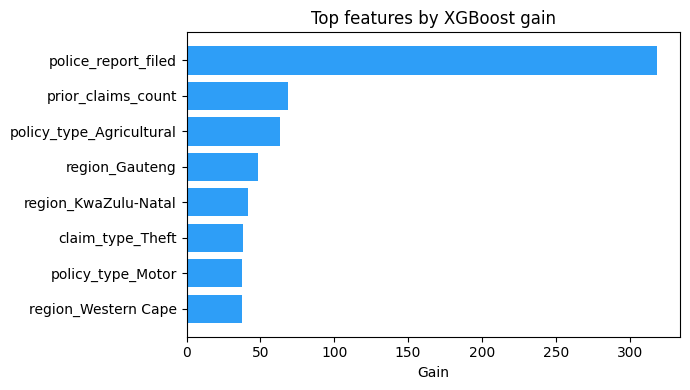

In [7]:
top_features = pd.DataFrame(get_top_features(model, feature_names, top_n=8))
plt.figure(figsize=(7, 4))
plt.barh(top_features['feature'][::-1], top_features['gain'][::-1], color='#2E9EF7')
plt.xlabel('Gain')
plt.title('Top features by XGBoost gain')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=110)
plt.show()

## Limitations

- **Synthetic data.** Every number in this notebook comes from the generator in `src/generate_data.py`, not real claims. The fraud-generating logic there is a documented, simplified simulation, not a fitted model of real fraud behaviour.
- **Small positive class.** ~370 fraud cases across the full dataset. Categorical features with many levels (region, claim type) show up in the feature-importance ranking with more weight than their true (zero, by construction) signal — a known risk when a high-cardinality categorical meets a small positive class, and worth watching for in the real pipeline too.
- **No temporal structure.** Real claims data has seasonality and drift; this generator doesn't model either.
- **Single train/test split.** A production evaluation would use cross-validation and a held-out time period, not one split.

## Reproducing this

```
pip install -r ../requirements.txt
python ../src/generate_data.py
python ../src/train_model.py
```